In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from pfapack import pfaffian as pf

We assume the form 

$$X = e^{\frac{1}{4}\gamma^T A \gamma}$$

which is characterized by 

$$\eta, B$$

In [ ]:
def get_eta_B(A):

    B = scipy.linalg.expm(-A)

    sinhA = scipy.linalg.sinhm(A/4)

    bdim = B.shape[0]

    M = np.zeros((2*bdim, 2*bdim), dtype = np.complex128)

    M[0:bdim, 0:bdim] = np.sqrt(2) * sinhA
    M[bdim:,0:bdim]   = np.identity(bdim)
    M[0:bdim,bdim:]   = -np.identity(bdim)
    M[bdim:,bdim:]    = np.sqrt(2) * sinhA

    eta = np.power(-1,bdim//2) * pf.pfaffian(M)

    return eta, B

def multiplication(eta1, B1, eta2, B2):

    bdim = B1.shape[0]

    M = np.zeros((2*bdim, 2*bdim), dtype = np.complex128)

    G1 = (np.identity(bdim) - B1) @ scipy.linalg.inv(np.identity(bdim) + B1)
    G2 = (np.identity(bdim) - B2) @ scipy.linalg.inv(np.identity(bdim) + B2)

    M[0:bdim, 0:bdim] = G1
    M[bdim:,0:bdim]   = np.identity(bdim)
    M[0:bdim,bdim:]   = -np.identity(bdim)
    M[bdim:,bdim:]    = G2

    eta12 = np.power(-1,bdim//2) * eta1 * eta2 * pf.pfaffian(M)

    B12   = B1@B2

    return eta12, B12


def generate_random_Alist(N, Ntau, scaling = 0.1):

    Alist = []
    rng = np.random.default_rng(seed = 412425)

    for i in range(Ntau):

        A = rng.normal(loc = 0, scale = scaling, size = (2*N, 2*N)) + 1j * rng.normal(loc = 0, scale = scaling, size = (2*N, 2*N))
        A = 0.5*(A - A.T)
        Alist.append(A)

    return Alist


class HMC():

    def __init__(self, t_MD, N_MD, model, saver, seed = 1337):
        self.N_MD = N_MD
        self.t_MD  = t_MD
        self.dt, self.dt_half = t_MD/self.N_MD, 0.5*t_MD/self.N_MD
        self.model = model
        self.cfg_shape = model.shape
        self.saver = saver
        self.steps = self.acc = 0
        self.rng   = np.random.default_rng(seed)


    def step(self):

        self.mom = self.rng.normal(loc = 0.0, scale = 1.0, size = self.cfg_shape).astype(np.complex128)
        new_cfg  = np.copy(self.model.cfg)
        old_H    = self.model.action + 0.5 * np.sum(np.power(self.mom, 2))
        self.mom -= self.dt_half*self.model.get_action_gradient(new_cfg)

        for _ in range(self.N_MD-1):

            new_cfg  +=self.dt*self.mom
            self.mom -= self.dt*self.model.get_action_gradient(new_cfg)
        
        new_cfg   += self.dt*self.mom
        self.mom  -= self.dt_half*self.model.get_action_gradient(new_cfg)
        new_action = self.model.get_action_catterpiller(new_cfg)

        new_H = new_action + 0.5* np.sum(np.power(self.mom, 2))
        dH    = new_H - old_H

        p = np.exp(-dH)
        r = self.rng.random()

        if r < p :

            self.acc += 1
            self.model.cfg = new_cfg
            self.model.action = new_action

        self.steps += 1


    def save(self):
        self.model.update_obs()
        self.saver.save_cfg_and_obs(self.model.cfg, self.model.obs_dict)

    def output_acc(self):
        return self.acc/self.steps
        
    def reset_acc(self):
        self.acc = self.steps = 0

    def output_model(self):
        return self.model

    def close_file(self):
        self.saver.close()



class Kitaev_action():
    def __init__(self, L, U, Delta, mu, dtau, Ntau, seed = 153525):
        #set paramters and initialize configuration     
        self.U = U
        self.mu = mu
        self.dtau = dtau
        self.Ntau = Ntau
        self.Delta = Delta
        self.L = L
        self.Dplus = 1 + Delta
        self.Dminus = 1 - Delta

        self.rng = np.random.default_rng(seed)
        self.shape = (L, Ntau)
        self.cfg = self.rng.normal(loc=0.0, scale = 1/np.sqrt(np.prod(self.shape)), size = self.shape).astype(np.complex128)
        self.gradient = np.zeros((self.cfg.shape), dtype=self.cfg.dtype)
        self.J = np.array([[0,-1],[1,0]])
        self.I = np.eye(2)
        self.eye = np.eye(2*self.L)

        self.A_odd = np.zeros((2*L, 2*L), dtype = np.complex128)
        self.A_odd[:L,:L] = np.roll(np.eye(L)*self.Dminus, 1, axis = 1) - np.roll(np.eye(L)*self.Dminus, -1, axis = 1)
        self.A_odd[L:,L:] = np.roll(np.eye(L)*self.Dplus, 1, axis = 1) - np.roll(np.eye(L)*self.Dplus, -1, axis = 1)

        self.A_odd[:L,L:] = np.eye(L)*mu
        self.A_odd[L:,:L] = -np.eye(L)*mu

        self.A_odd[L-1, 0] = 0
        self.A_odd[0, L-1] = 0

        self.A_odd[2*L - 1, L] = 0
        self.A_odd[L, 2*L-1]   = 0

        self.A_odd = self.A_odd * self.dtau * 1j

        self.eta_odd, self.B_odd = get_eta_B(self.A_odd)
        self.G_odd = scipy.linalg.tanhm(self.A_odd/2)
        self.expminusA = scipy.linalg.expm(-self.A_odd)
        self.expplusA  = scipy.linalg.expm(self.A_odd)
        self.eta_odd_prod = np.power(self.eta_odd, self.Ntau)

        self.temp = np.zeros((4*self.L, 4*self.L), dtype = np.complex128)
        self.temp[2*self.L:, :2*self.L] = np.eye(2*self.L)
        self.temp[:2*self.L, 2*self.L:] = -np.eye(2*self.L)

        self.g = np.zeros((self.Ntau*self.L*4, self.Ntau*self.L*4))

        block_size = 2 * L
        total_size = block_size * Ntau *2

        self.g = np.zeros((total_size, total_size), dtype=np.complex128)
        I = np.eye(block_size, dtype=np.complex128)

        for i in range(2*Ntau):
            for j in range(i + 1, 2*Ntau):
                # Checkerboard sign on upper triangle:
                # starts with minus for (i,j) = (0,1)
                sign = -1 if (j - i) % 2 == 1 else 1

                row_i = slice(i * block_size, (i + 1) * block_size)
                row_j = slice(j * block_size, (j + 1) * block_size)

                self.g[row_i, row_j] = sign * I
                self.g[row_j, row_i] = -sign * I  # antisymmetry

        self.action = self.get_action_catterpiller(self.cfg)

    def get_all_G_even(self, cfg):

        all_G_even = np.zeros((2*self.L, 2*self.L, self.Ntau), dtype =  np.complex128)
        temp       = (np.eye(self.cfg.shape[0], dtype=np.complex128) * np.tan(self.dtau*cfg.T[:, None, :])).transpose(1, 2, 0)

        all_G_even[self.L:, :self.L,:] = +temp
        all_G_even[:self.L, self.L:,:] = -temp
        
        return all_G_even
        
    
    def get_all_As(self, cfg):

        allAs = np.zeros((2 * self.Ntau, 2 * self.L, 2 * self.L), dtype=np.complex128)

        allAs[0::2] = self.A_odd

        d = 2 * self.dtau * cfg.T  # shape: (Ntau, L)

        I = np.arange(self.L)
        allAs[1::2, I, I + self.L] = - d
        allAs[1::2, I + self.L, I] = + d

        return allAs
    
    def get_g(self, cfg):
        
        block_size = 2 * self.L
        i = np.arange(self.L)

        t = np.tan(self.dtau * cfg.T)   # (Ntau, L)

        for j in range(self.Ntau):
            odd_base = 2 * j * block_size
            self.g[odd_base:odd_base + block_size,
                odd_base:odd_base + block_size] = self.G_odd

            even_base = (2 * j + 1) * block_size
            self.g[even_base + i,         even_base + self.L + i] = -t[j]
            self.g[even_base + self.L + i, even_base + i]         =  t[j]

    
    def get_action_catterpiller(self, cfg):

        two_to_the_L = 2**self.L

        L = self.L
        Ntau = self.Ntau
        n = 2 * L
        dtau = self.dtau
        U = self.U

        sign_eta = np.power(-1, self.L)

        action_B  = np.sum(2*cfg*cfg)/(self.dtau*self.U) # auxiliarry action

        current_G = self.G_odd.copy()
        current_B = self.expminusA.copy()
        current_eta = self.eta_odd

        allBs = np.zeros((n, n), dtype=np.complex128)
        allGs = np.zeros((n, n), dtype=np.complex128) 

        x = dtau * cfg
        tan_x = np.tan(x)
        cos_x = np.cos(x)
        cos_2x = np.cos(2.0*x)
        sin_2x = np.sin(2.0*x)

        alletas = np.prod(cos_x, axis = 1) * sign_eta

        idx = np.arange(L)
        idxL = idx + L

        for i in range(self.Ntau):
            c = cos_2x[:, i]
            s = sin_2x[:, i]
            t = tan_x[:, i]

            allBs.fill(0.0)
            allBs[idx,  idx]  = c
            allBs[idxL, idxL] = c
            allBs[idx,  idxL] = s
            allBs[idxL, idx]  = -s

            allGs.fill(0.0)
            allGs[idx,  idxL] = - t
            allGs[idxL, idx]  = + t
            
            #allBs[:,:]        = get_I_cross(np.diag(np.cos(2 * self.dtau * cfg[:,i]))) - get_J_cross(np.diag(np.sin(2*self.dtau*cfg[:,i])))
            #alletas           = cos_string(cfg[:,i], self.dtau)
            #allGs[:,:]        = get_J_cross(np.diag(np.tan(self.dtau * cfg[:,i])))

            self.temp[:n, :n] = current_G
            self.temp[n:, n:] = allGs[:,:]
            current_eta                     *= sign_eta * alletas[i] * pf.pfaffian(self.temp)
            current_B                       = current_B @ allBs
            current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')

            if i != (self.Ntau - 1):
                self.temp[:n, :n] = current_G
                self.temp[n:, n:] = self.G_odd
                current_eta                     *= sign_eta * self.eta_odd * pf.pfaffian(self.temp)
                current_B                       = current_B @ self.expminusA
                current_G                       = scipy.linalg.solve(self.eye + current_B, self.eye - current_B, assume_a='gen')

        weight = two_to_the_L * current_eta

        #This looks odd because in the case of the Kitaev chain and the way I HS-transformed A^up and A^down are equal, therefore the log must appear twice.
        # Perhaps a different HS-Trafo would be better
        self.action = action_B - 2.0*np.log(weight)

        return self.action
    
    
    def get_action_gradient(self, cfg):

        dtau = self.dtau
        L = self.L
        Ntau = self.Ntau
        block_size = 2 * L

        x = dtau * cfg
        tan_x = np.tan(x)
        sec2_x = 1.0 + tan_x * tan_x

        gradient_p1 = -dtau * tan_x

        self.get_g(cfg)

        t_idx = np.arange(Ntau)[:, None]
        x_idx = np.arange(L)[None, :]

        rows = ((2 * t_idx + 1) * block_size + x_idx).ravel()
        cols = (rows + L).ravel()

        # Solve only for needed columns of g^{-1}
        E = np.eye(self.g.shape[0], dtype=self.g.dtype)[:, cols]
        X = scipy.linalg.solve(self.g, E, assume_a='gen')

        g_inv_diag = X[rows, np.arange(rows.size)].reshape(Ntau, L).T

        gradient_p2 = dtau * g_inv_diag * sec2_x

        gradient_S_B = 4.0 * cfg / (dtau * self.U)

        gradient = -2.0 * (gradient_p1 + gradient_p2) + gradient_S_B
        return gradient
    

    
    def get_action_gradient_catterpiller(self, cfg):

        L = self.L
        Ntau = self.Ntau
        n = 2 * L
        dtau = self.dtau

        x = self.dtau * cfg
        tan_x = np.tan(x)
        cos_2x = np.cos(2*x)
        sin_2x = np.sin(2*x)
        tan_sq_p1 = 1 + tan_x*tan_x

        gradient = 2*dtau * tan_x

        gradient += 4*cfg/(dtau * self.U)

        S = np.eye(n, dtype = np.complex128)
        Gks = self.get_all_G_even(cfg)

        Beven = np.zeros((n, n), dtype=np.complex128)
        idx = np.arange(L)
        idxL = idx + L

        Beven = np.zeros((n, n, Ntau), dtype=np.complex128)
  
        for i in range(Ntau):

            c = cos_2x[:, i]
            s = sin_2x[:, i]

            Beven[idx,  idx, i]  = c
            Beven[idxL, idxL, i] = c
            Beven[idx,  idxL, i] = s
            Beven[idxL, idx, i]  = -s

            S = S @ self.expminusA
            S = S @ Beven[:,:,i]

        currentB = S
        B_i = np.eye(n, dtype=np.complex128)

        for i in range(Ntau):

            currentB = self.expplusA @ currentB @ B_i
            B_i      = self.expminusA

            currentB = Beven[:,:,i].T @ currentB @ B_i
            B_i      = Beven[:,:,i]

            Denominator = self.eye + currentB
            Enumerator  = self.eye - currentB

            M = Gks[:, :, i] @ Enumerator + Denominator
            temp_grad = scipy.linalg.solve(M.T, Enumerator.T, assume_a='gen').T

            temp_grad = np.diagonal(temp_grad[:L,L:]) * dtau * tan_sq_p1[:,i]
        
            gradient[:,i] -= 2.0*temp_grad

        self.gradeint = gradient
            
        return gradient



In [50]:
L = 6
U = 1
Delta = 0.2
mu = 2
dtau = 0.1
Ntau = 2

model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)
maction = model.get_action_catterpiller(model.cfg)

allAs = model.get_all_As(model.cfg)

grad = model.get_action_gradient(model.cfg)

grad_cat = model.get_action_gradient_catterpiller(model.cfg)

print(grad)
print(grad_cat)

print(grad - grad_cat)
print(np.allclose(grad, grad_cat))

[[ 1.13524971e+01-0.03910596j -4.84187309e+00-0.03910532j]
 [-8.73111108e-01-0.03872505j  6.00064699e+00-0.03872484j]
 [ 8.38627129e-04-0.03880535j -1.93445090e+01-0.0388086j ]
 [-1.28969362e+01-0.03876838j -1.51976027e+00-0.03876632j]
 [-1.34945291e+01-0.03873801j  4.23563913e+00-0.03873648j]
 [-4.38455946e+00-0.03913284j -8.38939561e+00-0.03913392j]]
[[ 1.13524971e+01-0.03910596j -4.84187309e+00-0.03910532j]
 [-8.73111108e-01-0.03872505j  6.00064699e+00-0.03872484j]
 [ 8.38627129e-04-0.03880535j -1.93445090e+01-0.0388086j ]
 [-1.28969362e+01-0.03876838j -1.51976027e+00-0.03876632j]
 [-1.34945291e+01-0.03873801j  4.23563913e+00-0.03873648j]
 [-4.38455946e+00-0.03913284j -8.38939561e+00-0.03913392j]]
[[ 0.00000000e+00-6.24500451e-17j  0.00000000e+00-4.85722573e-17j]
 [ 0.00000000e+00-1.38777878e-17j  0.00000000e+00+6.93889390e-18j]
 [ 3.46944695e-18+4.16333634e-17j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+1.38777878e-17j  0.00000000e+00-2.77555756e-17j]
 [ 0.00000000e+00+2.08

In [40]:
L = 6
U = 1
Delta = 0.2
mu = 0
dtau = 0.1
Ntau = 2
t_MD = 0.8
N_MD = 3


model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)
algorithm = HMC(t_MD, N_MD, model, saver = 0, seed = 3432)

for i in range(1000):
    algorithm.step()

algorithm.reset_acc()

for i in range(1000):
    algorithm.step()
algorithm.output_acc()

0.687

(0.9658843218947372+0j)
0.9658843218947372


In [ ]:
catterpillar(Alist)

In [ ]:
brute_force_trace(Alist)

In [ ]:
recursive_eta(Alist)

In [22]:
def get_G(A):

    D = scipy.linalg.inv(np.eye(A.shape[0]) + A)
    Nu= np.eye(A.shape[0]) - A

    return D @ Nu

In [23]:
Alist = generate_random_Alist(2, 3)

eta_1, B1 = get_eta_B(Alist[0])
eta_2, B2 = get_eta_B(Alist[1])
eta_3, B3 = get_eta_B(Alist[2])

eta_12, B12 = multiplication(eta_1, B1, eta_2, B2)
eta_21, B21 = multiplication(eta_2, B2, eta_1, B1)


G = get_G(B12)
Ginv = scipy.linalg.inv(G)
Gmb = get_G(-B12)


print(Ginv-Gmb)
print(Gmb)


[[-9.76996262e-15+8.93729535e-15j -8.43769499e-15+0.00000000e+00j
   6.21724894e-15+5.32907052e-15j -8.88178420e-15-5.32907052e-15j]
 [-1.77635684e-15-1.06581410e-14j  5.32907052e-15+2.10942375e-15j
   8.88178420e-16+3.55271368e-15j -1.77635684e-15+5.32907052e-15j]
 [ 3.55271368e-15-3.55271368e-15j  2.66453526e-15-3.55271368e-15j
  -2.73298669e-15-2.61028144e-15j  3.55271368e-15+3.21964677e-15j]
 [-3.55271368e-15+0.00000000e+00j  0.00000000e+00+1.77635684e-15j
   0.00000000e+00+2.77555756e-15j -3.66373598e-15-6.66133815e-16j]]
[[ 5.32907052e-15-8.93729535e-15j  2.89730090e+00-2.80885611e+01j
  -6.86373882e+00-1.06029205e+01j  9.15212804e+00-8.52026845e+00j]
 [-2.89730090e+00+2.80885611e+01j  4.08562073e-14+1.25455202e-14j
   4.55891552e+00-1.64369006e+01j -4.17989506e+00+9.24370871e+00j]
 [ 6.86373882e+00+1.06029205e+01j -4.55891552e+00+1.64369006e+01j
   2.55524768e-15-6.99440506e-15j -1.58647439e+01+7.62096081e-01j]
 [-9.15212804e+00+8.52026845e+00j  4.17989506e+00-9.24370871e+00j
  

In [24]:
Alist = generate_random_Alist(2, 4)

eta_1, B1 = get_eta_B(Alist[0])
eta_2, B2 = get_eta_B(Alist[1])
eta_3, B3 = get_eta_B(Alist[2])
eta_4, B4 = get_eta_B(Alist[3])

eta_12, B12 = multiplication(eta_1, B1, eta_2, B2)
eta_123, B123 = multiplication(eta_12, B12, eta_3,B3)
eta_1234, B1234 = multiplication(eta_123, B123, eta_4, B4)

eta_34, B34 = multiplication(eta_3, B3, eta_4, B4)
eta_341, B341 = multiplication(eta_34, B34, eta_1, B1)
eta_3412, B3412 = multiplication(eta_341, B341, eta_2, B2)

print(eta_3412)
print(eta_1234)

(0.9908392818070638-0.008791531664595042j)
(0.9908392818070639-0.008791531664595037j)


In [25]:

L = 6
U = 1
Delta = 0.2
mu = 0
dtau = 0.1
Ntau = 2
t_MD = 0.8
N_MD = 5


model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)

grad_1 = model.get_action_gradient_catterpiller(model.cfg)
grad_2 = model.get_action_gradient(model.cfg)

print(grad_1)
print(grad_2)

0
1
[[ 1.13526216e+01+0.j -4.84175304e+00+0.j]
 [-8.73017239e-01+0.j  6.00074997e+00+0.j]
 [ 4.86888909e-04+0.j -1.93448715e+01+0.j]
 [-1.28971985e+01+0.j -1.52001789e+00+0.j]
 [-1.34946962e+01+0.j  4.23547753e+00+0.j]
 [-4.38479785e+00+0.j -8.38963804e+00+0.j]]
[[ 1.13526216e+01+0.j -4.84175304e+00+0.j]
 [-8.73017239e-01+0.j  6.00074997e+00+0.j]
 [ 4.86888909e-04+0.j -1.93448715e+01+0.j]
 [-1.28971985e+01+0.j -1.52001789e+00+0.j]
 [-1.34946962e+01+0.j  4.23547753e+00+0.j]
 [-4.38479785e+00+0.j -8.38963804e+00+0.j]]


In [26]:
model.cfg[:,:] = np.arange(0, model.L*model.Ntau).reshape(model.L,model.Ntau)
out = (np.eye(model.cfg.shape[0], dtype=model.cfg.dtype) * model.cfg.T[:, None, :]).transpose(1, 2, 0)
print(model.cfg)
print(out[:,:,1])

[[ 0.+0.j  1.+0.j]
 [ 2.+0.j  3.+0.j]
 [ 4.+0.j  5.+0.j]
 [ 6.+0.j  7.+0.j]
 [ 8.+0.j  9.+0.j]
 [10.+0.j 11.+0.j]]
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  3.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  5.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  7.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  9.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j 11.+0.j]]


In [27]:
Alist = model.get_all_As(model.cfg)

eta_list = np.zeros(2*model.Ntau, dtype = np.complex128)
Blist    = np.zeros((2*model.L, 2*model.L, model.Ntau*2), dtype = np.complex128)

for i in range(2*Ntau):
    eta_list[i], Blist[:,:,i] = get_eta_B(Alist[i])


eta_c, Bc = eta_list[0], Blist[:,:,0]

for i in range(2*model.Ntau-1):

    eta_c, Bc = multiplication(eta_c, Bc, eta_list[i+1], Blist[:,:,i+1])


k = 2 #0 in code is 1 on paper


eta_k, Bk = eta_list[(k+1)%(2*model.Ntau)], Blist[:,:,(k+1) % (2*model.Ntau)]

for i in range(2*model.Ntau-1):
    print((k+i+2)%(2*model.Ntau))
    eta_k, Bk = multiplication(eta_k, Bk, eta_list[(k+i+2)%(2*model.Ntau)], Blist[:,:,(k+i+2)%(2*model.Ntau)])


print(eta_c*np.power(2, model.L))
print(eta_k*np.power(2, model.L))


0
1
2
(0.5814041850237394+0j)
(0.5814041850237389+0j)


In [28]:
def grad(sself, cfg):
        
        sself.get_g(cfg)

        g_inv = scipy.linalg.inv(sself.g)

        t = np.arange(sself.Ntau)[:, None]
        x = np.arange(sself.L)[None, :]

        rows = (2*t + 1) * (2*sself.L) + x
        cols = rows + sself.L

        g_inv_diag = g_inv[rows, cols].reshape(sself.Ntau, sself.L)

        gradient_p2 = sself.dtau * g_inv_diag.T*(1 + np.power(np.tan(sself.dtau*cfg), 2))

        return gradient_p2

def grad_c(self, cfg):

        S = np.eye(2*self.L)

        Gks = self.get_all_G_even(cfg)

        gradient = cfg.copy()*0

        for i in range(self.Ntau):

            S = S @ self.expminusA
            S = S @ (np.kron(self.I, np.diag(np.cos(2*self.dtau*cfg[:,i]))) - np.kron(self.J, np.diag(np.sin(2*self.dtau*cfg[:,i]))))

        currentB = S.copy()
        B_i = np.eye(self.L*2)

        for i in range(self.Ntau):

            currentB = self.expplusA @ currentB @ B_i

            B_i      = self.expminusA

            currentB = self.get_expplusAeven(cfg[:, i]) @ currentB @ B_i

            B_i      = self.get_expminusAeven(cfg[:,i])

            Denominator = self.eye + currentB
            Enumerator  = self.eye - currentB

            InverseFactor = scipy.linalg.inv(Gks[:,:,i]@Enumerator + Denominator)

            temp_grad = Enumerator @ InverseFactor
            temp_grad = np.diagonal(temp_grad[:self.L,self.L:]) * self.dtau * (1 + np.power(np.tan(self.dtau*cfg[:,i]),2))

            gradient[:,i] = temp_grad.copy()            


        return gradient

In [29]:
L = 6
U = 1
Delta = 0.2
mu = 0
dtau = 0.1
Ntau = 2
t_MD = 0.8
N_MD = 5


model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)

g1 = grad(model, model.cfg)
g2 = grad_c(model, model.cfg)

print(g1)
print(g2)

print(np.allclose(g1, g2))

[[ 1.19743871e-03+0.j -2.79420269e-03+0.j]
 [-1.44204260e-03+0.j  1.57536555e-04+0.j]
 [ 4.70648917e-03+0.j  8.15146901e-06+0.j]
 [ 3.39250125e-04+0.j  3.12276064e-03+0.j]
 [-1.07974545e-03+0.j  3.28054436e-03+0.j]
 [ 2.04337856e-03+0.j  1.09426710e-03+0.j]]
[[ 1.19743871e-03+0.j -2.79420269e-03+0.j]
 [-1.44204260e-03+0.j  1.57536555e-04+0.j]
 [ 4.70648917e-03+0.j  8.15146901e-06+0.j]
 [ 3.39250125e-04+0.j  3.12276064e-03+0.j]
 [-1.07974545e-03+0.j  3.28054436e-03+0.j]
 [ 2.04337856e-03+0.j  1.09426710e-03+0.j]]
True


In [50]:
model.cfg

print(np.prod(model.cfg, axis = 1).shape)

(6,)


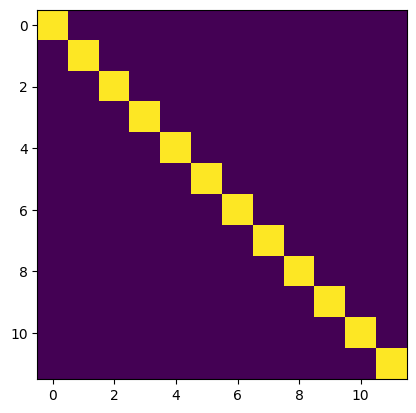

[[ 1.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  -3.08294779e-18+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  1.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  6.31518612e-20+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  1.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  2.90568152e-18+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   1.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  -2.12708830e-18+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0

In [11]:
a = model.get_expminusAeven(model.cfg[:,0])
b = a @ a.T

plt.imshow(np.abs(b))
plt.show()
print(b)

In [51]:
L = 8
U = 1
Delta = 0.2
mu = 2
dtau = 0.1
Ntau = 6

Nrun = 1000

model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)

for i in range(Nrun):
    grad = model.get_action_gradient(model.cfg)




In [52]:
L = 8
U = 1
Delta = 0.2
mu = 2
dtau = 0.1
Ntau = 6

Nrun = 1000

model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)

for i in range(Nrun):
    grad = model.get_action_gradient_catterpiller(model.cfg)


